In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 40


In [3]:
def load_hc18_multi_input_data(image_dir, csv_path):
    df = pd.read_csv(csv_path)

    images = []
    pixel_sizes = []
    labels = []

    for _, row in df.iterrows():
        filename = row["filename"]
        img_path = os.path.join(image_dir, filename)

        if not os.path.exists(img_path):
            continue

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=-1)

        images.append(img)
        pixel_sizes.append(row["pixel size(mm)"])
        labels.append(row["head circumference (mm)"])

    X_img = np.array(images, dtype=np.float32)
    X_pixel = np.array(pixel_sizes, dtype=np.float32).reshape(-1, 1)
    y = np.array(labels, dtype=np.float32)

    return X_img, X_pixel, y


In [4]:
X_img, X_pixel, y = load_hc18_multi_input_data(
    image_dir="training_set",
    csv_path="training_set_pixel_size_and_HC.csv"
)

X_img_train, X_img_val, \
X_pixel_train, X_pixel_val, \
y_train, y_val = train_test_split(
    X_img, X_pixel, y,
    test_size=0.2,
    random_state=42
)


In [5]:
pixel_scaler = StandardScaler()

X_pixel_train = pixel_scaler.fit_transform(X_pixel_train)
X_pixel_val   = pixel_scaler.transform(X_pixel_val)


In [6]:
def cnn_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    return x


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])


In [ ]:
# Image branch
image_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
x = data_augmentation(image_input)

x = cnn_block(x, 32)
x = cnn_block(x, 64)
x = cnn_block(x, 128)
x = cnn_block(x, 256)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# Pixel size branch
pixel_input = layers.Input(shape=(1,))
p = layers.Dense(32, activation="relu")(pixel_input)
p = layers.Dense(32, activation="relu")(p)

# Fusion
combined = layers.Concatenate()([x, p])
combined = layers.Dense(64, activation="relu")(combined)
combined = layers.Dropout(0.3)(combined)

output = layers.Dense(1, activation="linear")(combined)

model = models.Model(
    inputs=[image_input, pixel_input],
    outputs=output
)


In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.Huber(delta=10.0),
    metrics=["mae"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        320 │ sequential[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 434,145 (1.66 MB)

 Trainable params: 433,185 (1.65 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
history = model.fit(
    [X_img_train, X_pixel_train],
    y_train,
    validation_data=([X_img_val, X_pixel_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 420ms/step - loss: 1650.3683 - mae: 170.0368 - val_loss: 1726.3967 - val_mae: 177.6397
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 358ms/step - loss: 1564.3899 - mae: 161.4390 - val_loss: 1709.3927 - val_mae: 175.9393
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 421ms/step - loss: 1377.9971 - mae: 142.7993 - val_loss: 1647.3723 - val_mae: 169.7372
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 442ms/step - loss: 1047.9504 - mae: 109.7141 - val_loss: 1533.3148 - val_mae: 158.3315
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 356ms/step - loss: 687.5078 - mae: 73.6154 - val_loss: 901.2109 - val_mae: 94.9916
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 376ms/step - loss: 438.5904 - mae: 48.6237 - val_loss: 792.7500 - val_mae: 84.1714
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 439ms/step - loss: 406.0232 - mae: 45.3792 - val_loss: 481.8550 - val_mae: 53.0270
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 511ms/step - loss: 368.4606 - mae: 41.5918 - val_loss: 384.7023 - v

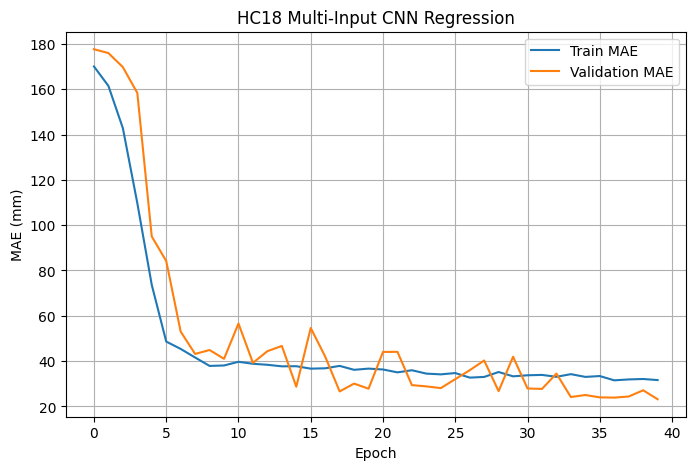

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (mm)")
plt.title("HC18 Multi-Input CNN Regression")
plt.legend()
plt.grid()
plt.savefig("hc18_cnn.pdf",format="pdf", bbox_inches="tight")
plt.show()


In [12]:
val_loss, val_mae = model.evaluate(
    [X_img_val, X_pixel_val],
    y_val
)

print(f"Validation MAE: {val_mae:.2f} mm")


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - loss: 186.9299 - mae: 23.1797
Validation MAE: 23.18 mm


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step


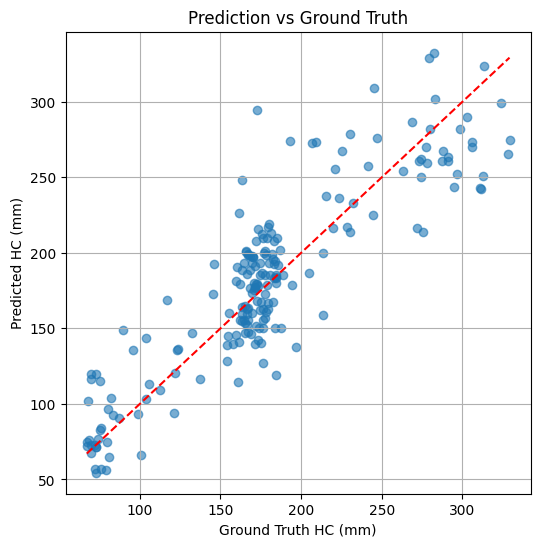

In [13]:
y_pred = model.predict([X_img_val, X_pixel_val]).flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Ground Truth HC (mm)")
plt.ylabel("Predicted HC (mm)")
plt.title("Prediction vs Ground Truth")
plt.grid()
plt.show()
